# Evaluator-optimiser: 이야기 개요 개선

**대상:** Python 함수와 async/await에 익숙한 Agent 입문자.

**학습 목표:** 생성 → 평가 → 피드백 반영 → 통과 또는 반복 상한 종료 과정을 Agent 정의와 실행 셀로 직접 구성합니다.

**순서:** 환경 준비 → 입력·Agent 정의 → 실행 → 결과 확인 → 작은 실습.

소스 코드 · 예제 안내 · 환경 설정

### 패턴 구조

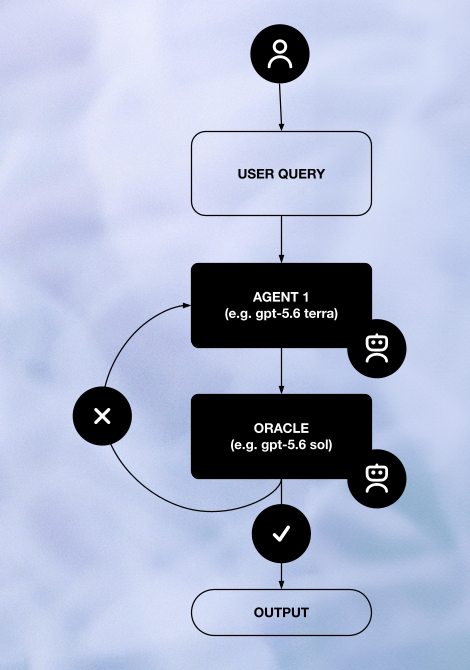

### 그림을 코드로 읽기

| 그림의 구성 요소 | 코드 구현 | 역할 |
| --- | --- | --- |
| User Query | `topic` | 생성할 이야기의 주제 |
| Agent 1 | `generator` | 이야기 개요를 생성하고 피드백을 반영 |
| Oracle | `evaluator`와 `Feedback` | 결과를 평가하고 구조화된 피드백을 반환 |
| Failure loop | `feedback.score != "pass"` | 피드백을 입력 기록에 추가하고 재생성 |
| Success path | `feedback.score == "pass"` | 반복을 종료 |
| Output | `outline` | 최종 이야기 개요 |

#### 실행 흐름

1. `generator`가 최초 이야기 개요를 생성합니다.
2. `evaluator`가 결과를 `Feedback` 형식으로 평가합니다.
3. 통과하지 못하면 피드백을 `history`에 추가하고 다시 생성합니다.
4. 통과하거나 `MAX_ROUNDS`에 도달하면 반복을 종료합니다.

#### 그림과 이 예제의 차이

그림은 Oracle이 생성 Agent보다 판단 능력이 높은 모델이라는 전제를 보여줍니다. 이 예제는 제어 흐름에 집중하기 위해 `generator`와 `evaluator`에 같은 `MODEL`을 사용합니다. 실제 품질 관리에서는 evaluator에 별도의 더 신뢰도 높은 모델이나 평가 기준을 적용해야 합니다.

## 1. 환경 준비

`uv`로 공통 Notebook 환경을 설치한 뒤 해당 커널을 선택하세요. `find_dotenv()`가 현재 위치 또는 상위 디렉터리의 `.env.local`을 찾지만 키 값은 출력하지 않습니다. 기존 환경 변수가 우선합니다.

기본 `RUN_API=False`에서는 Agent 구성과 오프라인 검증만 실행합니다. API 결과를 보려면 다음 셀에서 `RUN_API=True`로 변경하고 아래 셀을 순서대로 실행하세요. 모델 호출 및 웹 검색에는 비용이 발생할 수 있습니다. Notebook에서는 `asyncio.run()` 대신 최상위 `await`를 사용합니다.

In [ ]:
import os

from agents import Agent, Runner, set_tracing_disabled
from dotenv import find_dotenv, load_dotenv

# Look for .env.local in the current working directory and its parents.
env_path = find_dotenv(filename=".env.local", usecwd=True)

if not env_path:
    raise FileNotFoundError(
        "Could not find .env.local in the current directory or any parent directory."
    )

load_dotenv(env_path, override=False)
MODEL = os.getenv("AGENT_MODEL", "gpt-5.6-luna")
RUN_API = False  # Set to True to make real API calls.
set_tracing_disabled(True)  # Disable trace uploads by default for this tutorial.

if RUN_API and not os.getenv("OPENAI_API_KEY"):
    raise RuntimeError("Set OPENAI_API_KEY in your .env.local file.")

print({"model": MODEL, "api_enabled": RUN_API})

## 2. 생성기와 평가자 정의

구조화된 평가 결과로 다음 실행을 결정합니다. 교육용 상한은 품질 통과를 의미하지 않습니다.

In [ ]:
from typing import Literal

from pydantic import BaseModel


class Feedback(BaseModel):
    score: Literal["pass", "needs_improvement", "fail"]
    feedback: str


generator = Agent(
    name="Story writer",
    model=MODEL,
    instructions=(
        "Write a short story outline (under 120 words). "
        "Incorporate any feedback."
    ),
)

evaluator = Agent(
    name="Story evaluator",
    model=MODEL,
    output_type=Feedback,
    instructions=(
        "Pass only if the outline includes a detective, a space setting, "
        "a concrete mystery, and a resolution. Otherwise provide specific "
        "actionable feedback."
    ),
)

topic = "A detective story in space."
MAX_ROUNDS = 3

assert 1 <= MAX_ROUNDS <= 5

## 3. 피드백 루프 · API 호출

이전 실행의 입력 목록에 피드백을 붙입니다. `pass`에서 멈추거나 최대 횟수에 도달하면 종료합니다.

In [ ]:
history = [{"role": "user", "content": topic}]
rounds = []
outline = None
passed = False

if RUN_API:
    for round_number in range(1, MAX_ROUNDS + 1):
        draft = await Runner.run(generator, history, max_turns=2)
        history = draft.to_input_list()
        outline = str(draft.final_output)
        judged = await Runner.run(evaluator, outline, max_turns=2)
        feedback = judged.final_output
        rounds.append({"round": round_number, **feedback.model_dump()})

        print(round_number, feedback.score, feedback.feedback)

        if feedback.score == "pass":
            passed = True
            break

        history.append(
            {
                "role": "user",
                "content": (
                    "Improve the outline using this feedback: "
                    f"{feedback.feedback}"
                ),
            }
        )

    print("Passed" if passed else "Round limit reached without passing")
    print(outline)
else:
    print("API call skipped")

## 4. 종료 조건 확인

성공 여부와 상한 종료를 구별합니다.

In [ ]:
if RUN_API:
    assert 1 <= len(rounds) <= MAX_ROUNDS
    assert outline and outline.strip()
    assert passed or len(rounds) == MAX_ROUNDS
    assert passed == (rounds[-1]["score"] == "pass")

## 5. 별도 파일로 구성하기: `main()` 실행 진입점

앞의 셀은 실행 과정을 단계별로 살펴보기 위한 코드입니다. 아래는 같은 흐름을 하나의 Python 모듈로 구성한 추가 예제입니다. 이 섹션은 앞에서 만든 Agent나 전역 변수에 의존하지 않으므로, 환경에 패키지가 설치되어 있다면 이 코드 셀부터 실행할 수 있습니다.

두 Agent를 하나의 SDK Agent로 합치는 것이 아니라, **생성 Agent와 평가 Agent를 실행하는 워크플로를 함수로 묶습니다.** 원본처럼 `main()`을 진입점으로 두되, Notebook의 명시적인 평가 기준과 최대 반복 횟수는 유지합니다.

| 구성 | 책임 |
| --- | --- |
| `StoryFeedback` | 평가 결과의 형식 정의 |
| `build_story_agents()` | 생성기와 평가자 구성 |
| `refine_story()` | 생성 → 평가 → 개선 반복과 종료 처리 |
| `main()` | 환경 설정, 입력 전달, 결과 출력 |

API 실행 여부는 `main(run_api=...)`에서 지정합니다. 기본값은 `False`이며, 실제 호출을 켜면 비용이 발생합니다. 코드 셀을 실행하는 것만으로는 API를 호출하지 않습니다.


In [ ]:
import asyncio
import os
from typing import Literal

from agents import Agent, Runner, set_tracing_disabled
from dotenv import find_dotenv, load_dotenv
from pydantic import BaseModel


class StoryFeedback(BaseModel):
    score: Literal["pass", "needs_improvement", "fail"]
    feedback: str


def build_story_agents(model: str) -> tuple[Agent, Agent]:
    """Create the generator and evaluator for one workflow run."""
    generator = Agent(
        name="Story writer",
        model=model,
        instructions=(
            "Write a short story outline (under 120 words). "
            "Incorporate any feedback."
        ),
    )

    evaluator = Agent(
        name="Story evaluator",
        model=model,
        output_type=StoryFeedback,
        instructions=(
            "Pass only if the outline includes a detective, a space setting, "
            "a concrete mystery, and a resolution. Otherwise provide specific "
            "actionable feedback."
        ),
    )

    return generator, evaluator


async def refine_story(
    topic: str,
    *,
    model: str,
    max_rounds: int = 3,
) -> dict:
    """Refine an outline and return the result and evaluation history."""
    if not 1 <= max_rounds <= 5:
        raise ValueError("max_rounds must be between 1 and 5.")

    generator, evaluator = build_story_agents(model)
    history = [{"role": "user", "content": topic}]
    rounds = []
    outline = ""
    passed = False

    for round_number in range(1, max_rounds + 1):
        draft = await Runner.run(generator, history, max_turns=2)
        history = draft.to_input_list()
        outline = str(draft.final_output)

        judged = await Runner.run(evaluator, outline, max_turns=2)
        feedback = judged.final_output
        rounds.append({"round": round_number, **feedback.model_dump()})

        if feedback.score == "pass":
            passed = True
            break

        history.append(
            {
                "role": "user",
                "content": (
                    "Improve the outline using this feedback: "
                    f"{feedback.feedback}"
                ),
            }
        )

    return {"outline": outline, "passed": passed, "rounds": rounds}


async def main(
    topic: str = "A detective story in space.",
    *,
    run_api: bool = False,
    max_rounds: int = 3,
) -> dict | None:
    """Load configuration, run the workflow, and present its results."""
    env_path = find_dotenv(filename=".env.local", usecwd=True)

    if not env_path:
        raise FileNotFoundError(
            "Could not find .env.local in the current directory "
            "or any parent directory."
        )

    load_dotenv(env_path, override=False)
    model = os.getenv("AGENT_MODEL", "gpt-5.6-luna")
    set_tracing_disabled(True)

    if not run_api:
        print("API call skipped. Pass run_api=True to enable it.")
        return None

    if not os.getenv("OPENAI_API_KEY"):
        raise RuntimeError("Set OPENAI_API_KEY in your .env.local file.")

    result = await refine_story(topic, model=model, max_rounds=max_rounds)

    for evaluation in result["rounds"]:
        print(
            evaluation["round"],
            evaluation["score"],
            evaluation["feedback"],
        )

    print("Passed" if result["passed"] else "Round limit reached without passing")
    print(result["outline"])

    return result


### Notebook에서 호출하기

Jupyter는 이미 이벤트 루프를 실행하므로 `asyncio.run()` 대신 `await main(...)`을 사용합니다. 아래 셀은 기본적으로 호출을 생략합니다. 실습할 때 `run_api=True`로 바꾸세요. 앞의 단계별 API 실습을 실행했다면 여기서는 별도의 새 실행이 시작됩니다.


In [ ]:
standalone_result = await main(
    topic="A detective story in space.",
    run_api=False,  # Set to True to run this standalone workflow.
    max_rounds=3,
)


### `story_agent.py` 파일로 실행하기

1. 위의 **함수 정의 코드 셀 전체**를 `story_agent.py`에 복사합니다. Notebook 전용 `await main(...)` 호출 셀은 복사하지 않습니다.

2. 파일 맨 아래에 다음 진입점을 추가합니다. `--run-api`를 지정한 경우에만 API를 호출합니다.

   ```python
   if __name__ == "__main__":
       import argparse

       parser = argparse.ArgumentParser(description="Refine a story outline.")
       parser.add_argument("--run-api", action="store_true")
       args = parser.parse_args()

       asyncio.run(main(run_api=args.run_api))
   ```

3. 공통 실습 의존성이 설치된 가상환경을 활성화하고, `.env.local`이 있는 폴더 또는 그 하위에서 실행합니다.

   ```bash
   python story_agent.py            # Check configuration; skip API calls
   python story_agent.py --run-api  # Run the workflow; API costs apply
   ```

다른 Python 모듈에서 재사용할 때는 `from story_agent import refine_story`로 가져와 `await refine_story(topic, model=...)`을 호출할 수 있습니다. 이 경우 환경 변수와 tracing 설정은 호출하는 애플리케이션에서 준비합니다. `if __name__ == "__main__":` 블록 덕분에 import만으로 실행되지 않습니다.

이 추가 예제는 기존 `src/main.py`를 수정하거나 덮어쓰지 않습니다. 파일을 배포할 때는 이 Notebook의 출처와 저장소의 `THIRD_PARTY_NOTICES.md` 고지도 함께 유지하세요.


## 직접 바꿔보기

평가 기준에 “마지막 반전”을 추가하고 점수·피드백이 어떻게 바뀌는지 비교하세요. 더 강한 평가 모델을 사용한다면 별도 모델 변수로 지정하세요.

## 원본과 달라진 점 · 주의점

원본의 무제한 반복을 최대 3회로 제한하고, 첫 시도에 무조건 실패시키는 지침을 명시적 품질 기준으로 바꿨습니다. 같은 모델로 평가하므로 평가자의 우월한 판단력을 보장하지 않습니다.

## 출처

- [로컬 소스](../src/main.py)
- [OpenAI 공식 예제](https://github.com/openai/openai-agents-python/blob/25af629b3c877ba3d0e95189141bb636b21167a5/examples/agent_patterns/llm_as_a_judge.py)
- [Agents SDK 가이드](https://developers.openai.com/api/docs/guides/agents/sdk)
- [Agents 가이드](https://developers.openai.com/api/docs/guides/agents)

이 Notebook은 공식 예제를 학습용으로 재구성한 파일이며 원본의 단순 복사본은 아닙니다. 모델 출력은 실행마다 달라집니다.